Telco Customer Churn: Deep Learning with PyTorch

A standalone deep-learning notebook for the churn project. It runs the same preprocessing as Week 4/5, then trains a small feed-forward neural network in PyTorch and compares it against the strong classical baselines (Logistic Regression and Gradient Boosting) and IBM's own Churn Score.
It is a supervised binary classification problem with imbalanced classes (about 26.5% churn), so we judge models on precision, recall, F1, and ROC-AUC, not just accuracy.
Everything is self-contained: it downloads the data, prepares it, trains, and evaluates without needing any other notebook or saved file.

Obtain and prepare the data.

Same pipeline as Week 4/5: download from Kaggle, fix Total Charges, engineer three features, drop identifier/constant/leakage columns, split 80/20 stratified, then one-hot encode and scale with a ColumnTransformer fit on the training set only.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"   # tiny network; CPU keeps runs reproducible across machines
print("torch", torch.__version__, "| device", DEVICE)

torch 2.12.1 | device cpu


In [2]:
import kagglehub

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")   # 11 blanks -> NaN (0-tenure)
print(df.shape)

(7043, 33)


In [3]:
# Keep IBM's Churn Score aside as a benchmark (not a model feature)
churn_score_benchmark = df["Churn Score"].copy()

DROP_COLS = [
    "Count", "Country", "State",
    "CustomerID", "City", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason", "CLTV",
    "Churn Value",
]
ADDON_COLS = ["Online Security", "Online Backup", "Device Protection",
              "Tech Support", "Streaming TV", "Streaming Movies"]
NUMERIC_FEATURES = ["Tenure Months", "Monthly Charges", "Total Charges", "Num_Addon_Services"]
PASSTHROUGH_FEATURES = ["AutoPay", "IsNewCustomer"]

def add_features(data):
    data = data.copy()
    data["Num_Addon_Services"] = (data[ADDON_COLS] == "Yes").sum(axis=1)
    data["AutoPay"] = data["Payment Method"].str.contains("automatic", case=False).astype(int)
    data["IsNewCustomer"] = (data["Tenure Months"] <= 6).astype(int)
    return data

def clean_data(data):
    data = data.copy()
    data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce").fillna(0)
    return data.drop(columns=DROP_COLS)

def make_Xy(data):
    return clean_data(add_features(data)), data["Churn Value"]

In [4]:
X_all, y_all = make_Xy(df)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

categorical_features = [c for c in X_train_raw.columns
                        if c not in NUMERIC_FEATURES + PASSTHROUGH_FEATURES]
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categorical_features),
    ("bin", "passthrough", PASSTHROUGH_FEATURES),
])

X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_test  = preprocessor.transform(X_test_raw).astype("float32")
y_train = y_train.to_numpy().astype("float32")
y_test  = y_test.to_numpy().astype("float32")
churn_score_test = churn_score_benchmark.loc[X_test_raw.index].to_numpy()

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4), " Test churn rate:", round(y_test.mean(), 4))

X_train: (5634, 43)  X_test: (1409, 43)
Train churn rate: 0.2654  Test churn rate: 0.2654


Baselines. Before the neural network we fix the reference points: a no-skill model that always predicts stay (the floor), Logistic Regression, Gradient Boosting (the strongest classical tabular model and the one to beat), and IBM's Churn Score (the ceiling). All use the exact same train/test split.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

def metric_row(name, y_true, pred, score):
    return pd.Series({
        "accuracy":  accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "f1":        f1_score(y_true, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, score),
    }, name=name)

results = []

# No-skill: always predict "stay"
results.append(metric_row("Majority (stay)", y_test, np.zeros_like(y_test), np.zeros_like(y_test)))

logreg = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train, y_train)
results.append(metric_row("Logistic Regression", y_test, logreg.predict(X_test),
                          logreg.predict_proba(X_test)[:, 1]))

gbm = HistGradientBoostingClassifier(random_state=SEED).fit(X_train, y_train)
results.append(metric_row("Gradient Boosting", y_test, gbm.predict(X_test),
                          gbm.predict_proba(X_test)[:, 1]))

# IBM Churn Score is a continuous propensity; ROC-AUC only (no fixed threshold)
bench_auc = roc_auc_score(y_test, churn_score_test)
print("IBM Churn Score ROC-AUC:", round(bench_auc, 3))

pd.DataFrame(results).round(3)

IBM Churn Score ROC-AUC: 0.943


,accuracy,precision,recall,f1,roc_auc
Majority (stay),0.735,0.000,0.000,0.000,0.500
Logistic Regression,0.805,0.657,0.553,0.601,0.853
Gradient Boosting,0.800,0.642,0.556,0.596,0.846


The PyTorch network. A small feed-forward net: input -> 32 -> 16 -> 1.
Each hidden layer has batch normalization, a ReLU activation, and dropout to fight overfitting on this ~5,600-row training set.
The single output is a logit; we use BCEWithLogitsLoss with pos_weight set to the negative/positive ratio so the 26.5% churn imbalance does not push the network to always predict stay.
We hold out a validation split from the training data and stop early when validation loss stops improving.

In [6]:
# Train / validation split (for early stopping), stratified
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

Xtr_t  = torch.tensor(X_tr);  ytr_t  = torch.tensor(y_tr).unsqueeze(1)
Xval_t = torch.tensor(X_val); yval_t = torch.tensor(y_val).unsqueeze(1)
Xtest_t = torch.tensor(X_test)

loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))

n_features = X_train.shape[1]

class ChurnMLP(nn.Module):
    def __init__(self, n_in, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(32, 16),   nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
model = ChurnMLP(n_features).to(DEVICE)

pos_weight = torch.tensor([(y_tr == 0).sum() / (y_tr == 1).sum()], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)
print("pos_weight:", round(pos_weight.item(), 3))

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
pos_weight: 2.768


In [7]:
best_val = float("inf")
best_state = None
patience, wait = 15, 0

for epoch in range(200):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(Xval_t), yval_t).item()

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

model.load_state_dict(best_state)
print(f"Stopped at epoch {epoch} | best validation loss {best_val:.4f}")

Stopped at epoch 42 | best validation loss 0.6700


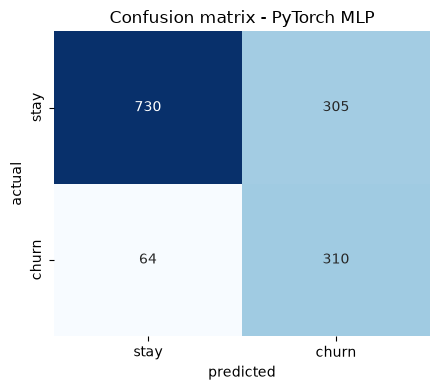

              precision    recall  f1-score   support

        stay       0.92      0.71      0.80      1035
       churn       0.50      0.83      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.75      1409



In [8]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(Xtest_t)).numpy().ravel()
pred = (probs >= 0.5).astype(int)

results.append(metric_row("PyTorch MLP", y_test, pred, probs))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["stay", "churn"], yticklabels=["stay", "churn"], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix - PyTorch MLP")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["stay", "churn"]))

Compare everything on the test set.

In [9]:
compare = pd.DataFrame(results).sort_values("f1", ascending=False)
compare.loc["IBM Churn Score (AUC only)"] = [np.nan, np.nan, np.nan, np.nan, bench_auc]
compare.round(3)

,accuracy,precision,recall,f1,roc_auc
PyTorch MLP,0.738,0.504,0.829,0.627,0.854
Logistic Regression,0.805,0.657,0.553,0.601,0.853
Gradient Boosting,0.800,0.642,0.556,0.596,0.846
Majority (stay),0.735,0.000,0.000,0.000,0.500
IBM Churn Score (AUC only),NaN,NaN,NaN,NaN,0.943


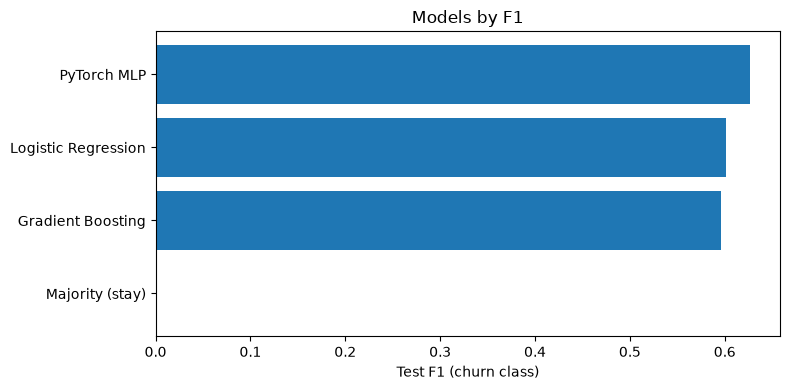

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = pd.DataFrame(results).sort_values("f1")
ax.barh(plot_df.index, plot_df["f1"])
ax.set_xlabel("Test F1 (churn class)")
ax.set_title("Models by F1")
plt.tight_layout()
plt.show()

The PyTorch network reaches the highest test F1 (0.63), a little above Logistic Regression (0.60) and Gradient Boosting (0.60), and its ROC-AUC (0.85) is essentially tied with them.
Most of that F1 edge comes from the pos_weight setting, which pushes recall to 0.83 (it catches most churners) at the cost of precision 0.50 (many false alarms) - the same high-recall, low-precision trade we saw from Naive Bayes in Week 5, not fundamentally better discrimination.
Judged by ROC-AUC, which does not depend on the threshold, the network ranks customers about as well as the classical models. That is the expected result on tabular data this size: a small neural net matches but does not clearly beat gradient boosting.
IBM's Churn Score still leads by a wide margin (AUC 0.94), the demanding benchmark to chase.
For Week 6 the network is worth keeping as the high-recall option: tuning the decision threshold, width and depth, dropout, and pos_weight could trade some recall back for precision, and it makes different errors than the tree and linear models, which is useful for an ensemble.